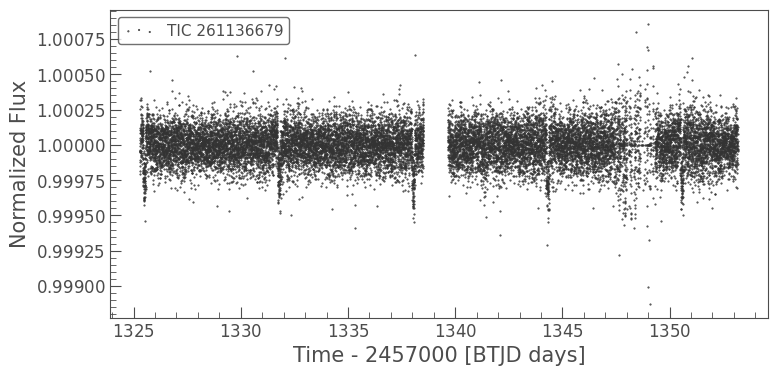

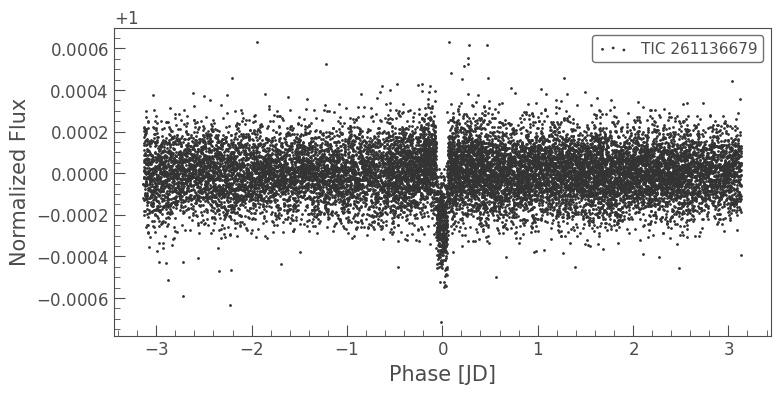

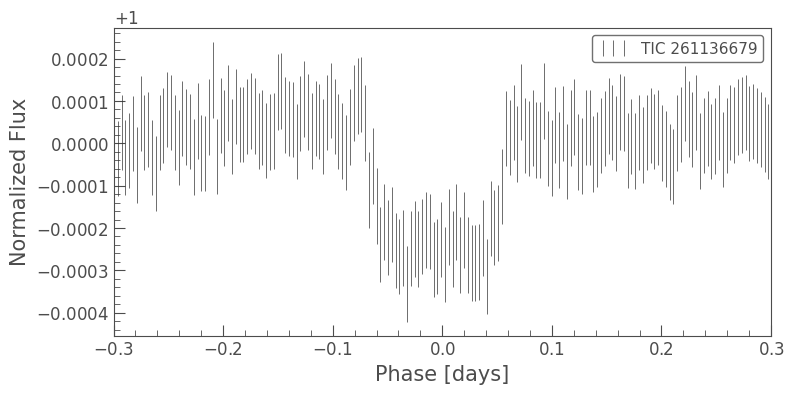

Period: 6.264329294710032 d
Transit duration: 0.1 d
Transit epoch (t0): 1325.5169604950604
Depth (from BLS): 0.00024754283270154954
Mean flux in transit: 0.9998017664847848
Mean flux out of transit: 1.00000441378709
Transit depth: 0.000203 (0.0203%, 202.6 ppm)
Estimated planet radius: 1.9739050852690325 Earth radii
    ID           ra               dec        ... wdflag     dstArcSec     
--------- ---------------- ----------------- ... ------ ------------------
261136679 84.2911879979852 -80.4691197969941 ...      0                0.0
261139071        84.257651         -80.46656 ...      0   22.0150762974544
724137557 84.2520122339161   -80.47060236557 ...      0 23.952493188275678
724137554 84.3377837896451 -80.4686446189646 ...      0  27.82836244863518
724137558 84.2799547508233 -80.4566970989506 ...      0  45.22085267562254
724137553  84.375451013625 -80.4667316207757 ...      0 50.964548485511756
261136683 84.3394605707539  -80.481100860134 ...      0   51.8391570947034
72413755

In [5]:

# MAIN CODE
#-----------------------------------------------------------------------------------------------------------------------------------------------------------------------------

# First we import library modules
import numpy as np
import matplotlib.pyplot as plt
import astropy.units as u
import lightkurve as lk

# Reading the lightcurve file
lc = lk.read(r"E:\abhijay\Astro\Astro Project\Raw data\TIC 261136679\MAST_2026-09-23T1607\MAST_2026-09-23T1607\TESS\tess2018206045859-s0001-0000000261136679-0120-s\tess2018206045859-s0001-0000000261136679-0120-s_lc.fits")



#Filtering out invalid data, in this case, data that are not numbers
lc = lc.remove_nans()

# Flattening the data: removing long term trends to focus on transit(short term) 
flat_lc = lc.flatten(window_length=1001) # Window length large to highlight short term trends(transit)
flat_lc.scatter(s=1)
plt.show() #Initial flatted plot shown in figure 1 in the 'Figures' file in README

# Remove the noisy part in figure 1, roughly from 1346-1350 days (x axis)
flat_lc = flat_lc[
    (flat_lc.time.value < 1346) |
    (flat_lc.time.value > 1350)
]

# Remove strong outliers (we keep  99.999999803% of the data)
flat_lc = flat_lc.remove_outliers(sigma=6)

# Working out period of transit by converting flattened lighcurve into a periodogram
periodogram = flat_lc.to_periodogram(method="bls")

best_period = periodogram.period_at_max_power #gives the period with the strongest signal

# Fold at the best period : used the determined period to stack all repeating cycles of the stellar orbit to essentially get a single dip in intensity
folded_lc = flat_lc.fold(
    period=6.27,
    epoch_time=1325.504 #reference time used to set the center of the fold
)
folded_lc.scatter() # Shown in figure 2 in the 'Figures' file in README
plt.show()

# Bin into 5-minute bins: produces a less noisier curve by grouping points in a 5 minute window into bins and averaging them
binned_lc = folded_lc.bin(
    time_bin_size=5*u.minute
)

# Plot
binned_lc.errorbar() # Plots the binned light curve with error bars


plt.xlim(-0.3, 0.3) # Zooming in on the transit so that its clearly visible

plt.xlabel("Phase [days]")
plt.ylabel("Normalized Flux")

plt.show() # Figure 3 in 'Figures' file in README


#Extracting data from the binned lc
best_t0 = periodogram.transit_time_at_max_power #Returns time of transit
best_depth = periodogram.depth_at_max_power #Returns transit depth
best_duration = periodogram.duration_at_max_power #Returns duration of transit
print("Period:", best_period) # Period of transit found to be 6.264329294710032 days.
print("Transit duration:", best_duration) # Duration of transit was found to be 0.1 days
print("Transit epoch (t0):", best_t0) # Time of transit found to be 1325.5169604950604 BTJD Days
print("Depth (from BLS):", best_depth) # Transit depth: 0.000203 (0.02475%, 247.5 ppm)

# Main code finished
#-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

# Manually verifying transit depth
phase = folded_lc.phase.value # Converts phase values from lc into numpy array
flux = folded_lc.flux.value #Converts flux values from lc into numpy array

# Dip in the plot from phase -0.07 to 0.07
in_transit = (phase > -0.07) & (phase < 0.07)
out_of_transit =~in_transit

mean_in_transit = np.nanmean(flux[in_transit])
mean_out_of_transit = np.nanmean(flux[out_of_transit])

 #Finding transit depth
depth_fraction = mean_out_of_transit - mean_in_transit
depth_percent = depth_fraction * 100
depth_ppm = depth_fraction * 1e6  # parts per million — common unit for small transits

print("Mean flux in transit:", mean_in_transit)
print("Mean flux out of transit:", mean_out_of_transit)
print(f"Transit depth: {depth_fraction:.6f} ({depth_percent:.4f}%, {depth_ppm:.1f} ppm)")

#------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

# Computing Radius Of planet

R_star_solar = 1.14889 #Known value of stellar radius of TIC 261136679 in units of soolar radii
depth = best_depth.value if hasattr(best_depth, 'value') else best_depth # Ensures a quantity oobject is returned when best_Depth is called

Radius_planet = np.sqrt(depth) * R_star_solar *109.2 # Calculates radius of planet using the relation: Depth = (R_planet / R_star )^2.
# Note: multiplying result by 109.5 is to convert the radius to units of Earth radii

# Printing deduced planet radius
print("Estimated planet radius:", Radius_planet, "Earth radii")

#---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------



# Checking data catalogue for TIC 261136679 to verify whether obtained transit depth and planet radius is true
from astroquery.mast import Catalogs

result = Catalogs.query_object("TIC 261136679", catalog="TIC")
print(result)

# See all available column names first
print(result.colnames)
star = result[result['ID'] == '261136679']
print("Radius (Solar radii):", star['rad'])
print("Temperature (K):", star['Teff'])
print("Mass (Solar masses):", star['mass'])

from astroquery.ipac.nexsci.nasa_exoplanet_archive import NasaExoplanetArchive

result_toi = NasaExoplanetArchive.query_criteria(
    table="toi", where="tid=261136679"
)
print(result_toi)
print(result_toi.colnames)
#Final Results 
print('Final results:')
print(f"Transit depth: {best_depth:.6f} ({best_depth*100:.4f}%, {best_depth * 1e6:.1f} ppm)")
print("Published transit depth:", result_toi['pl_trandep'])
print("Obtained Period:", best_period)
print("Published period:", result_toi['pl_orbper'])
print("Estimated planet radius:", Radius_planet, "Earth radii")
print("Published planet radius:", result_toi['pl_rade'])



